In this Notebook we are aiming to find clusters of accidents events causing personal injury in Frankfurt am Main. 

As a first step we are loading in all packages and our preprocessed data.

In [1]:
%load_ext autoreload
%autoreload 2
import geopandas as gpd
import matplotlib.pyplot as plt

from urban_mobility import fetch_data as fd
from urban_mobility import plotting as pl
from urban_mobility.clusters import analyze_clusters, knn_distances
from urban_mobility.utils import cached, load_config, resolve_path

fd.fetch_traffic_data()
cfg = load_config()

Already have 2016.csv, skipping...
Already have 2017.csv, skipping...
Already have 2018.csv, skipping...
Already have 2019.csv, skipping...
Already have 2020.csv, skipping...
Already have 2021.csv, skipping...
Already have 2022.csv, skipping...
Already have 2023.csv, skipping...
Already have 2024.csv, skipping...
Already have 2025.csv, skipping...


In [2]:
# Frankfurt accidents of all years, with readable names for the values in UTYP1
Frankfurt = fd.get_city_accidents("Frankfurt am Main", label_utyp1=True)
Frankfurt.head()

,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,UART,...,IstPKW,IstFuss,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,District_key
8575,06,4,12,000,2016,1,19,7,3,9,...,1,0,0,0.0,0,471854.4512,5.545148e+06,8.606800,50.057949,06412
8664,06,4,12,000,2016,1,0,1,3,2,...,1,0,0,0.0,0,465949.1018,5.551119e+06,8.523772,50.111344,06412
8978,06,4,12,000,2016,1,15,7,1,5,...,1,0,0,0.0,0,467209.1346,5.550947e+06,8.541409,50.109870,06412
9024,06,4,12,000,2016,1,2,1,2,0,...,1,0,0,0.0,0,475327.1534,5.547310e+06,8.655174,50.077547,06412
9074,06,4,12,000,2016,1,3,6,3,0,...,1,0,0,0.0,0,477911.2036,5.548912e+06,8.691196,50.092058,06412


As a first step we will try to get a rough Overview about the distribution of accidents events across the city. 
We can see that the accident spread across the entire city, with the highest concentration of accidents being close to it's center.
This is about what one would expect, so to get actual insights we need to dig deeper.

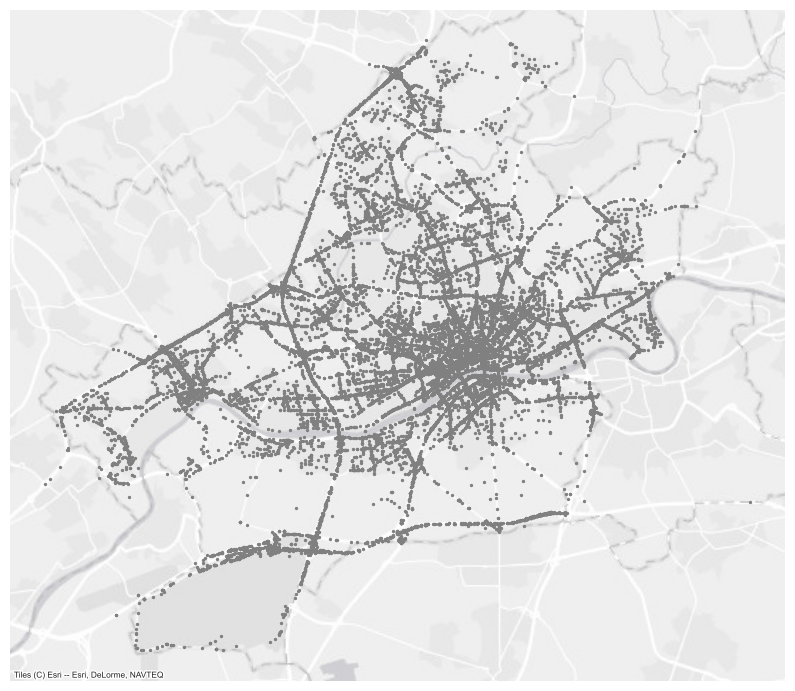

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
pl.point_map(Frankfurt, size=2, alpha=1, ax=ax)
plt.show()

As the next step, we are checking accident distribution across the city by creating weighted center points. For our Accident data, we calculate the mean location of accidents, and then compare those against the Geographical and Physical Center of Frankufrt. From the results we can see that the Mean accident Centers with Bicycle, Pedestrian, and Car involvement are closer to the Frankfurt city center then the Geographical Center points. Since that in itself is not to insightful either, we will need to deploy a clustering alogorithm to get some deeper insights.

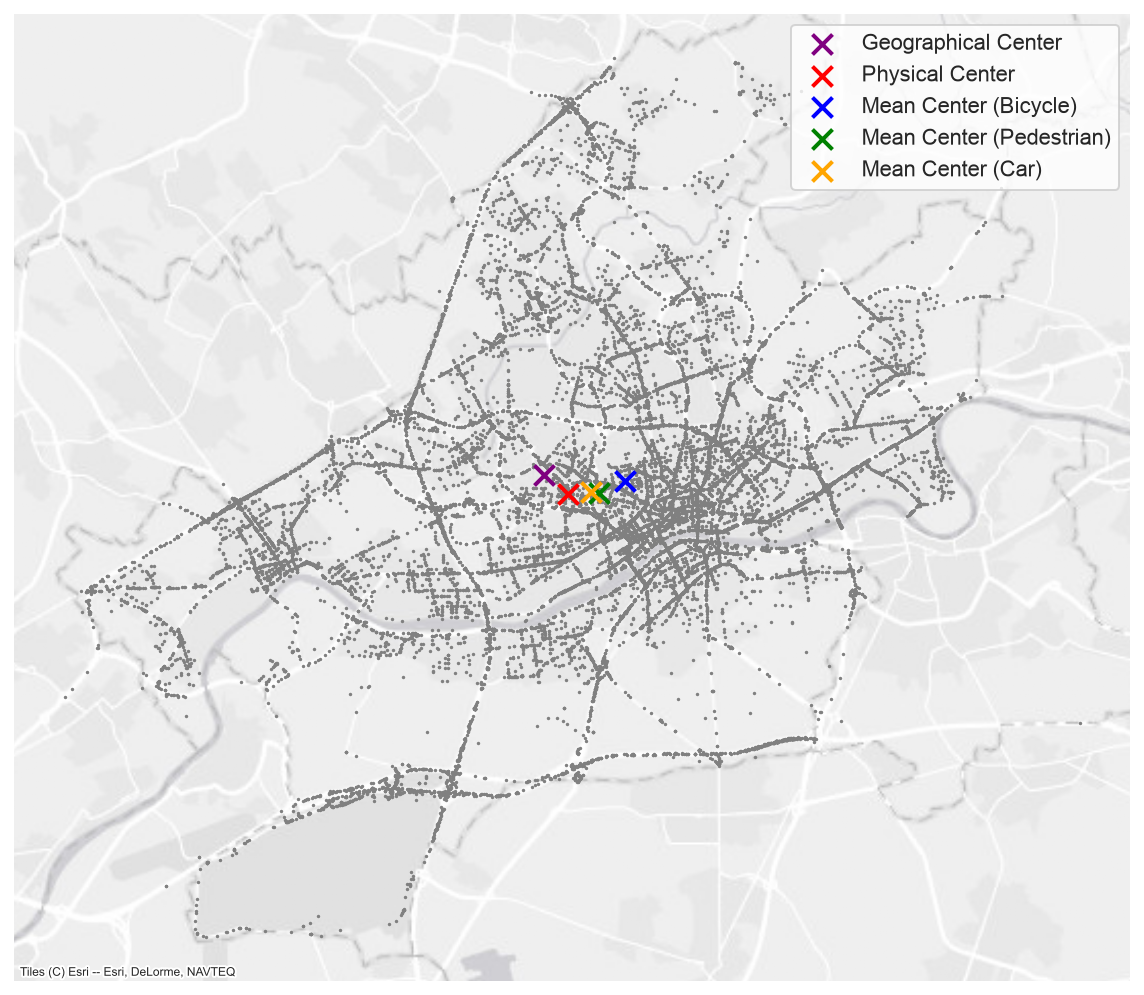

In [4]:
centers = pl.FFM_CENTERS + pl.mean_centers(
    Frankfurt,
    [
        ("IstRad", "blue", "Bicycle"),
        ("IstFuss", "green", "Pedestrian"),
        ("IstPKW", "orange", "Car"),
    ],
)

fig, ax = plt.subplots(figsize=(10, 10), dpi=144)
pl.point_map(Frankfurt, size=0.5, alpha=1, centers=centers, ax=ax)
plt.show()

# DBSCAN 
For this analysis, we are choosing to use the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm.
There are many potential Clustering algorithms that could be used on this dataset, but we chose DBSCAN specifically due to its favorable attributes for our analysis:
1. DBSCAN is a density-based algorithm, meaning it's specifically designed to find regions where points are packed closely together, which lines up with our goal
2. Accident hotspots comes in all kinds of shapes. A hotspot might follow a winding section of a highway, or form a "T" shape at a dangerous intersection. DBSCAN does not assume any        shapes, which lines up with our use-case.
3. For our analysis, we want to find systemic hotspots, and want to seperate them from random incidents. As DBSCAN allows for noise, it will exclude isolated points from our clusters rather then associate them with a cluster


To get started, we need to choose our input for the two main parameters that can be tuned with DBSCAN: Eps (ε) and and the minimum samples.
Since we have no good knowledge about which numbers could be appropriate, and one way of getting a good estimate is to use an Elbow curve with the sklearn NearestNeighbors alogirthm.

When we choose k = 20 as a starting point, and get the below curve. The result shows us that we can expect get a good clustering result if we choose ε to be between 350-400.
In our case though, we will use a slightly different approach. We assume that two accident events are related if they are within 100 meters of each other. Since we are only looking for the most dense areas, we will set eps = 100 and then scale our minimum samples until 5 or less clusters remain which then get analyzed based on the causes for the accidents.


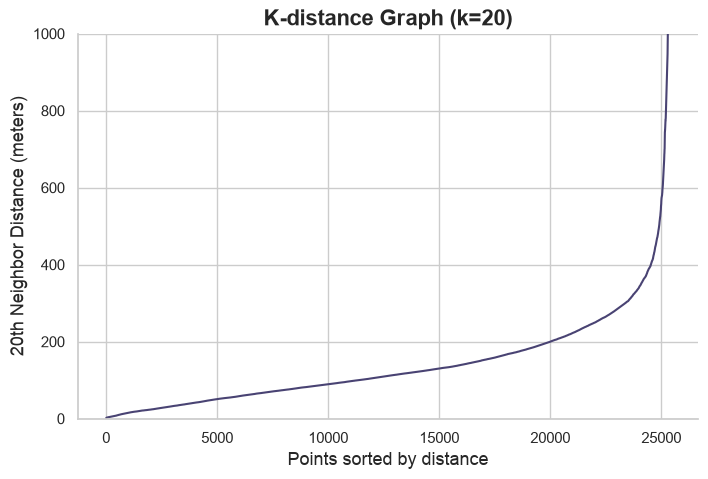

In [5]:
k = 20
fig, ax = plt.subplots(figsize=(8, 5))
pl.knn_distance(knn_distances(Frankfurt, k), k, f"K-distance Graph (k={k})", ax=ax)
ax.set_ylabel(f"{k}th Neighbor Distance (meters)")
ax.set_ylim(0, 1000)
plt.show()

First, we are plotting all accident events and see where the main hotspots for accidents of any kind are in Frankfurt. 
We achieve 5 or less clusters for a min samples value of 99, ε is fixed to 100. The result is the below cluster.
We examine Cluster 1 specifically due to its proximity to our Frankfurt School of Finance and Management.

Found 4 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.118727   8.731392   
1       50.131801   8.683856   
2       50.117373   8.679427   
3       50.107332   8.656074   

                                                                            Google_Maps_Link  
labels                                                                                        
0        https://www.google.com/maps/search/?api=1&query=50.11872731965657,8.731391607230478  
1        https://www.google.com/maps/search/?api=1&query=50.13180058384076,8.683855530106237  
2        https://www.google.com/maps/search/?api=1&query=50.11737305293274,8.679427026644273  
3       https://www.google.com/maps/search/?api=1&query=50.107332338584214,8.656074122633706  


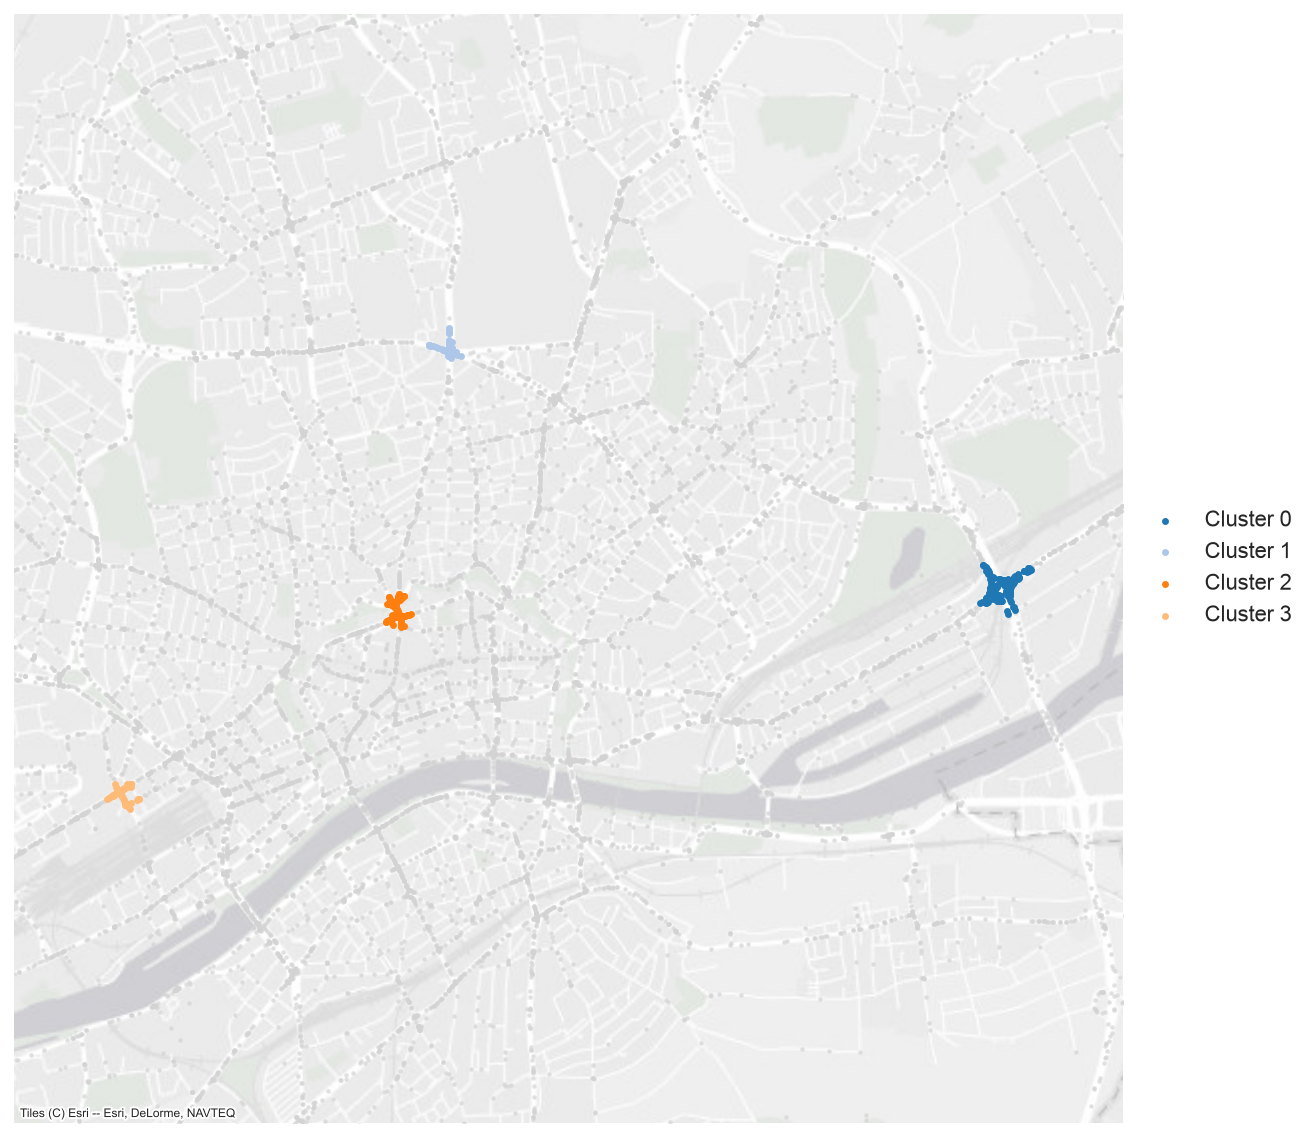

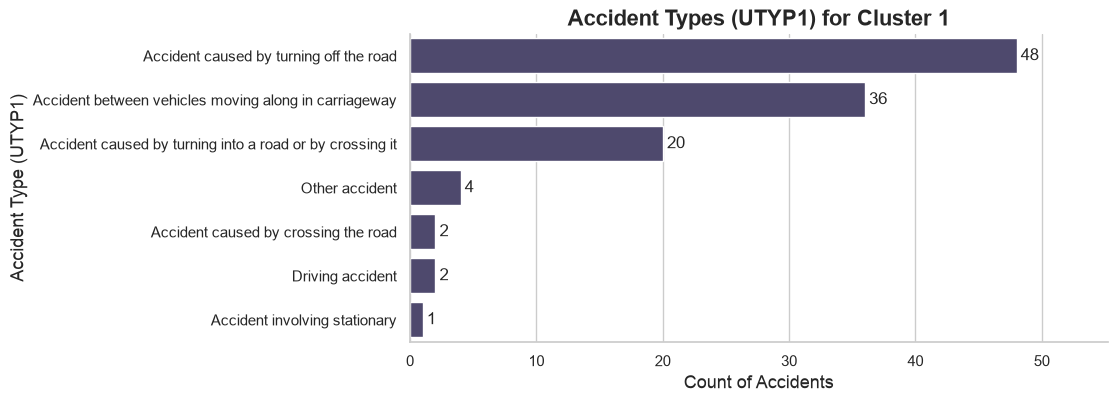

In [6]:
# All Accident events
all_clusters = analyze_clusters(Frankfurt, "all", eps=100, min_samples=99, cluster_to_plot=1, save_as="clusters_all_accidents")

In the next step, we are filtering the dataset to accidents that include bicycles. This does not exclude Pedestrians or Cars from the accidents, but makes sure every accident involves a cyclist. We keep ε fixed to 100, and achieve 5 Clusters for minimum samples = 46.

We are fetching the reasons for accidents in Cluster 3 due to its location next to the river.
We can see that the vast majority of accidents are caused by turning off the road, which means that cyclists are likely hit by cars when they leave the street for another direction.
The location can be inspected through the provided google maps link.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.131880   8.683753   
1       50.132517   8.695045   
2       50.107696   8.675652   
3       50.109342   8.694486   
4       50.107135   8.687705   

                                                                            Google_Maps_Link  
labels                                                                                        
0         https://www.google.com/maps/search/?api=1&query=50.13187969213798,8.68375346293108  
1       https://www.google.com/maps/search/?api=1&query=50.132516904717434,8.695045125521784  
2        https://www.google.com/maps/search/?api=1&query=50.10769604587505,8.675652326041712  
3         https://www.google.com/maps/search/?api=1&query=50.1093423788776,8.694485595428612  
4       https://www.google.com/maps/search/?api=1&query=50.107135454021794,8.687704615130485  


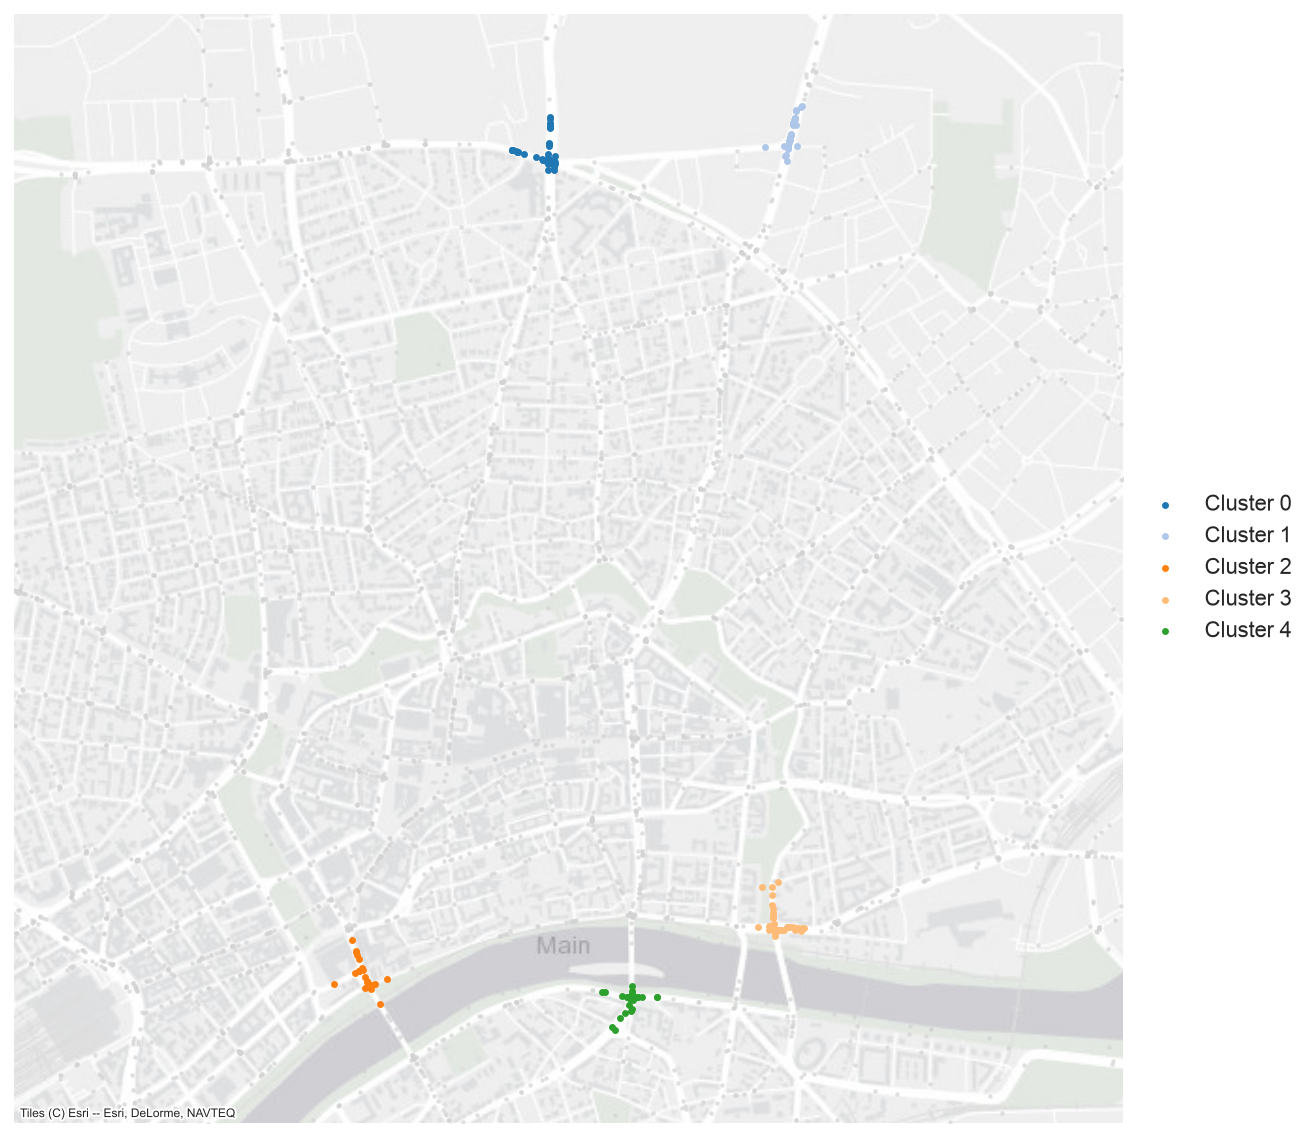

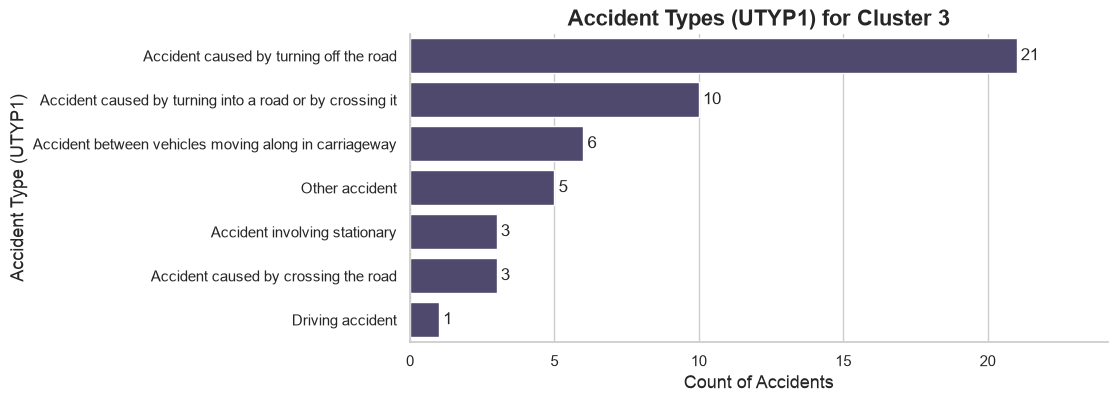

In [7]:
# Bicycle Clusters
bicycle_clusters = analyze_clusters(
    Frankfurt[Frankfurt["IstRad"] == 1],
    "bicycle",
    eps=100,
    min_samples=46,
    cluster_to_plot=3,
    save_as="clusters_cyclists",
)

In the next step, we are filtering the dataset to accidents that include pedestrians. We keep ε fixed to 100, and achieve 5 Clusters for minimum samples = 20. the low amount of minimum samples is needed due to the prevelance of pedestrians is rather low.

We are fetching the reasons for accidents in Cluster 1, the largest pedestrian cluster, near the Hauptbahnhof. Most of its accidents are caused by crossing the road.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.108724   8.662192   
1       50.108274   8.665771   
2       50.126960   8.692056   
3       50.114271   8.687763   
4       50.123177   8.701829   

                                                                            Google_Maps_Link  
labels                                                                                        
0       https://www.google.com/maps/search/?api=1&query=50.108724081680045,8.662192413320035  
1        https://www.google.com/maps/search/?api=1&query=50.10827397324215,8.665771070631623  
2        https://www.google.com/maps/search/?api=1&query=50.12696045100004,8.692056318280038  
3        https://www.google.com/maps/search/?api=1&query=50.11427130280397,8.687763470745145  
4        https://www.google.com/maps/search/?api=1&query=50.123177139500044,8.70182862185003  


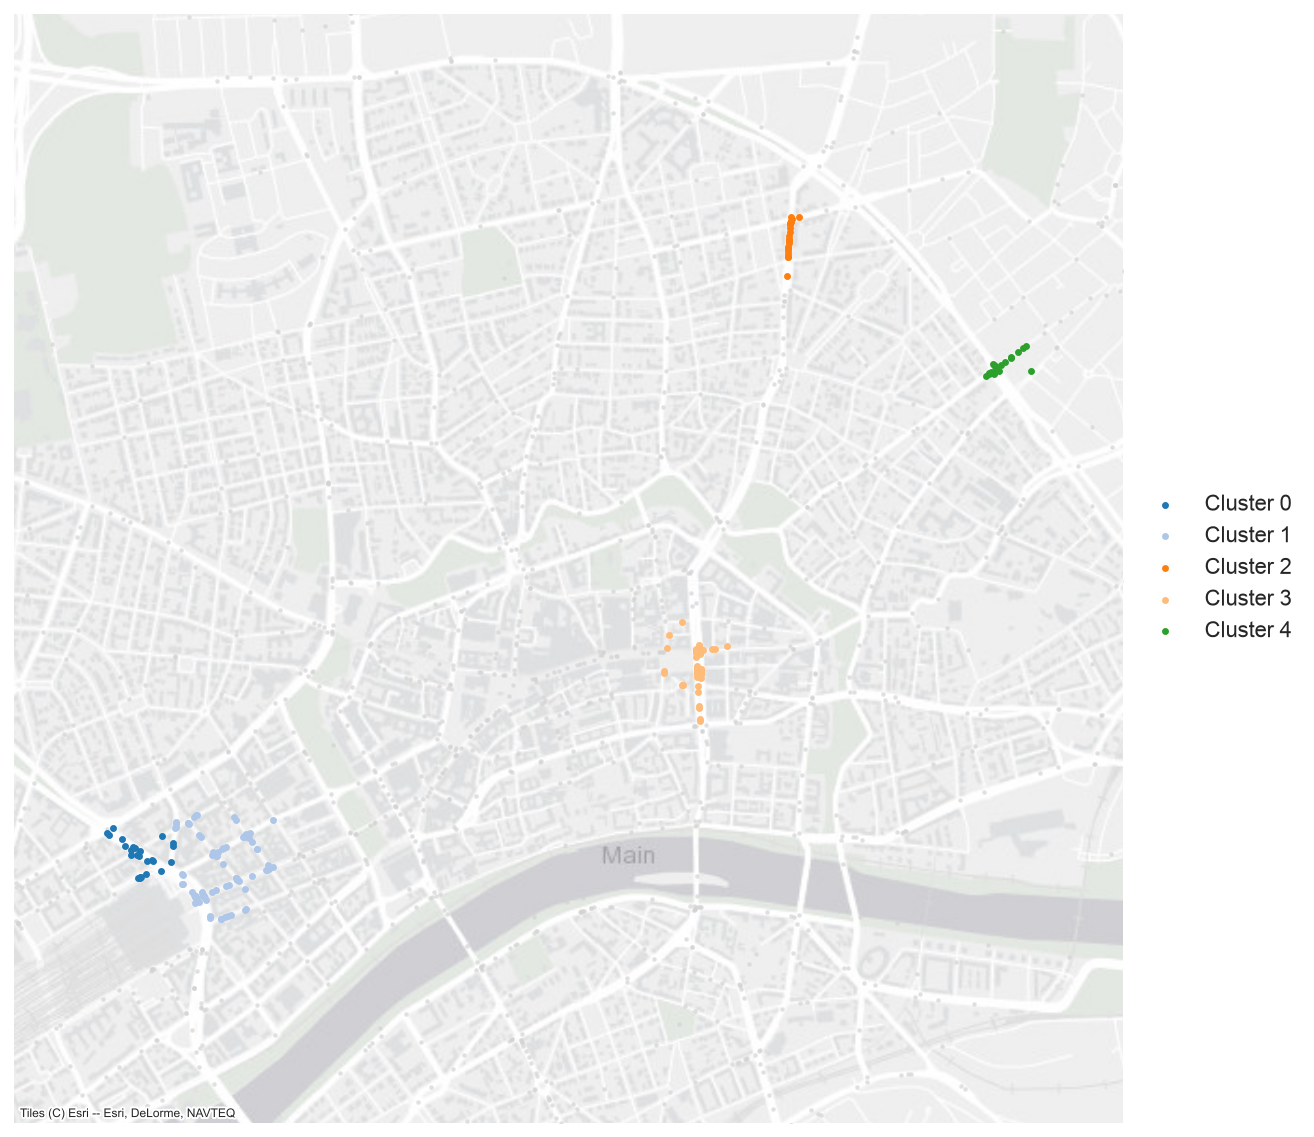

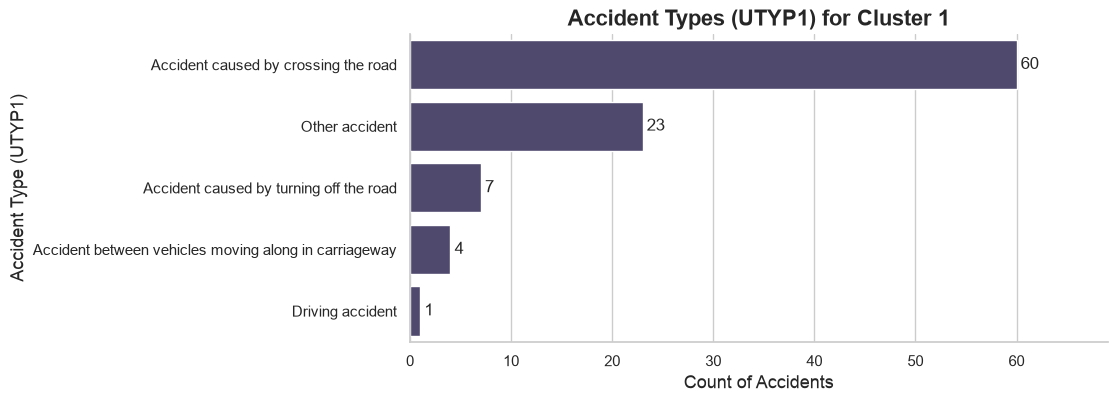

,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,UART,...,IstFuss,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,District_key,labels
10593,06,4,12,000,2016,2,13,3,1,6,...,1,0,1.0,0,478659.3040,5.552369e+06,8.701461,50.123180,06412,4
12869,06,4,12,000,2016,4,6,3,3,6,...,1,0,0.0,0,475825.3110,5.550796e+06,8.661916,50.108920,06412,0
13119,06,4,12,000,2016,4,17,2,3,6,...,1,0,0.0,0,476050.0200,5.550641e+06,8.665068,50.107535,06412,1
17145,06,4,12,000,2016,7,5,6,3,6,...,1,0,0.0,0,475982.7214,5.550676e+06,8.664125,50.107848,06412,1
17334,06,4,12,000,2016,8,22,5,3,6,...,1,0,0.0,0,475839.9499,5.550770e+06,8.662122,50.108690,06412,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195858,06,4,12,000,2025,10,19,4,3,6,...,1,0,0.0,1,477690.8651,5.551358e+06,8.687972,50.114051,06412,3
196626,06,4,12,000,2025,10,15,7,3,6,...,1,0,0.0,0,477678.1350,5.551374e+06,8.687793,50.114196,06412,3
196830,06,4,12,000,2025,12,14,7,3,0,...,1,0,0.0,1,477981.8800,5.552739e+06,8.691963,50.126478,06412,2
196850,06,4,12,000,2025,12,0,4,3,6,...,1,0,0.0,0,476079.8144,5.550773e+06,8.665477,50.108724,06412,1


In [8]:
# Pedestrian Clusters
pedestrian_clusters = analyze_clusters(
    Frankfurt[Frankfurt["IstFuss"] == 1],
    "pedestrian",
    eps=100,
    min_samples=20,
    cluster_to_plot=1,
    save_as="clusters_pedestrians",
)
pedestrian_clusters

We repeat the same process for Nighttime accidents.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.118501   8.731210   
1       50.100264   8.667509   
2       50.109733   8.687808   
3       50.107263   8.656204   
4       50.114530   8.687862   

                                                                           Google_Maps_Link  
labels                                                                                       
0         https://www.google.com/maps/search/?api=1&query=50.11850058294741,8.7312098492632  
1       https://www.google.com/maps/search/?api=1&query=50.100264392675726,8.66750854497302  
2        https://www.google.com/maps/search/?api=1&query=50.1097325042813,8.687807862781293  
3       https://www.google.com/maps/search/?api=1&query=50.10726306367862,8.656203788321474  
4       https://www.google.com/maps/search/?api=1&query=50.11453049732505,8.687861808050043  


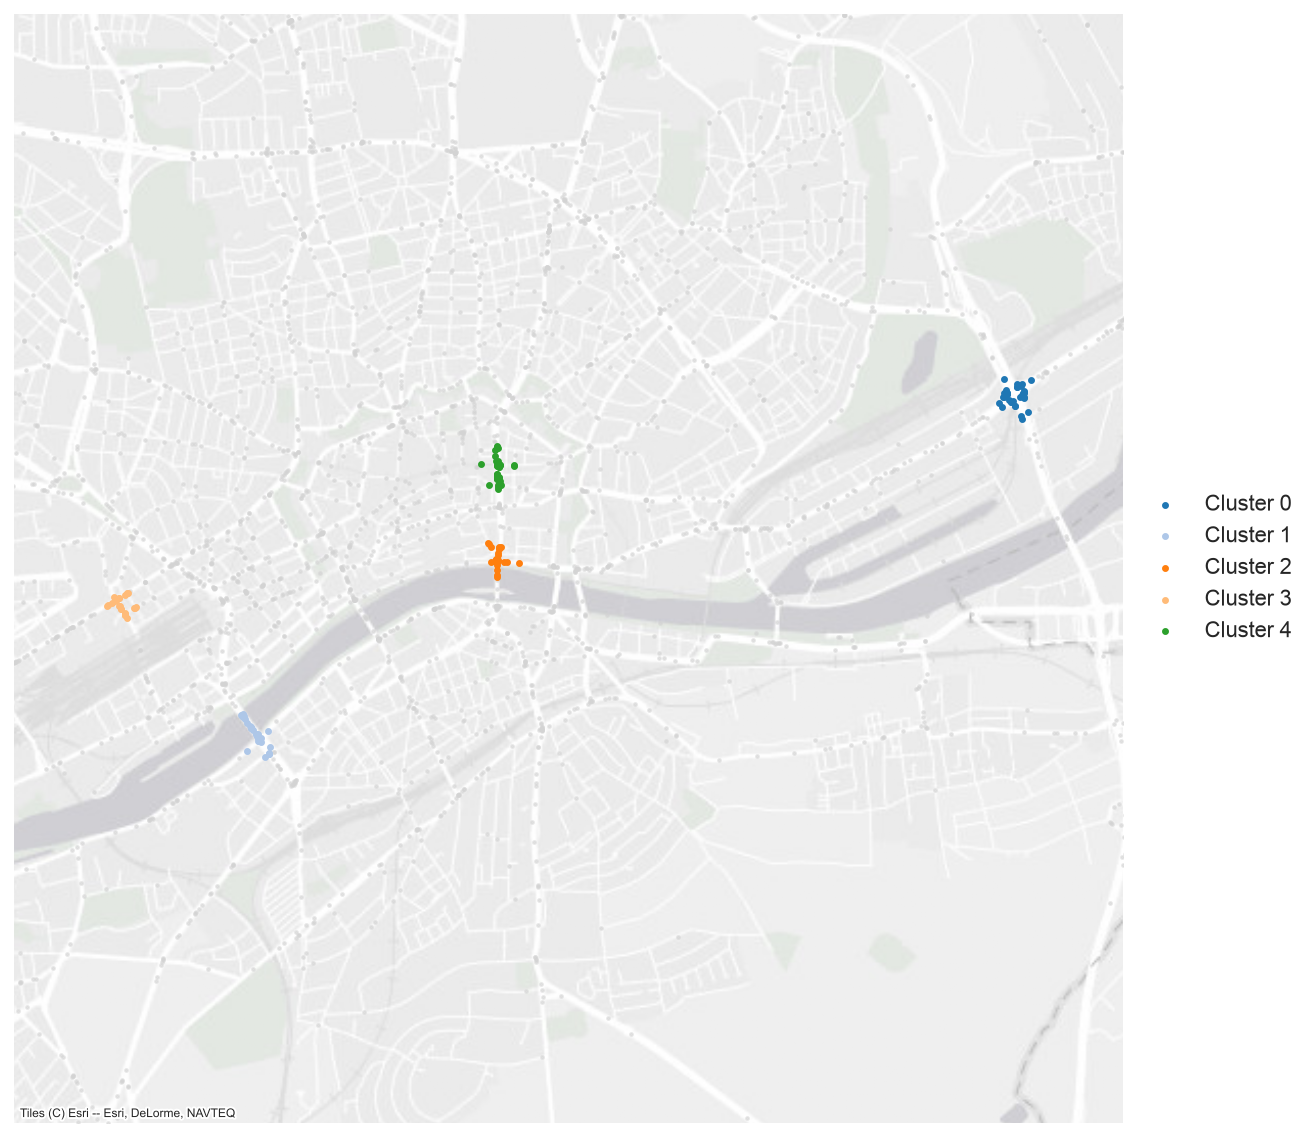

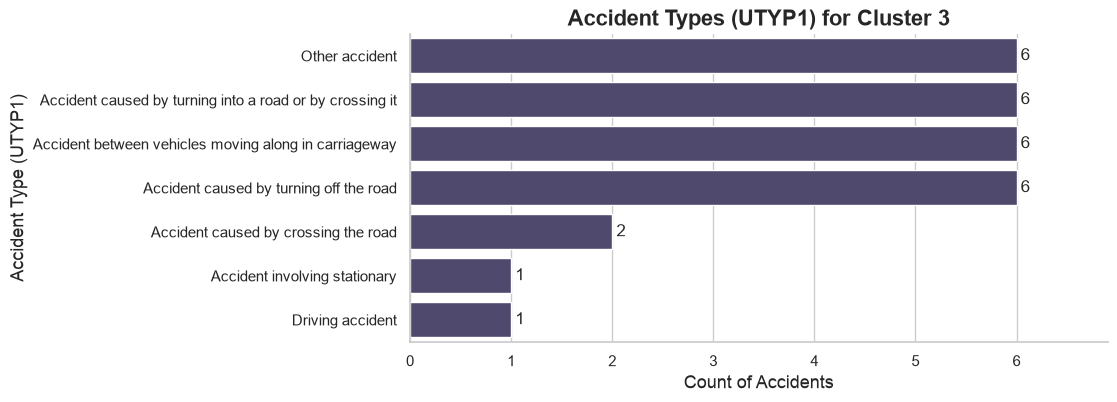

In [9]:
# Night time Clusters
night_clusters = analyze_clusters(
    Frankfurt[Frankfurt["ULICHTVERH"] == 2],
    "night",
    eps=100,
    min_samples=27,
    cluster_to_plot=3,
)

And lastly, we are looking at serious injuries.

Found 5 clusters.
Cluster Center Coordinates
         Latitude  Longitude  \
labels                         
0       50.106989   8.687452   
1       50.118604   8.731121   
2       50.107533   8.664659   
3       50.109207   8.694301   
4       50.139080   8.670190   

                                                                            Google_Maps_Link  
labels                                                                                        
0          https://www.google.com/maps/search/?api=1&query=50.1069886561177,8.68745214600004  
1       https://www.google.com/maps/search/?api=1&query=50.118603891400056,8.731121192840044  
2        https://www.google.com/maps/search/?api=1&query=50.107532818545515,8.66465881172732  
3       https://www.google.com/maps/search/?api=1&query=50.109206503705934,8.694300632647106  
4        https://www.google.com/maps/search/?api=1&query=50.13908031600005,8.670189867071471  


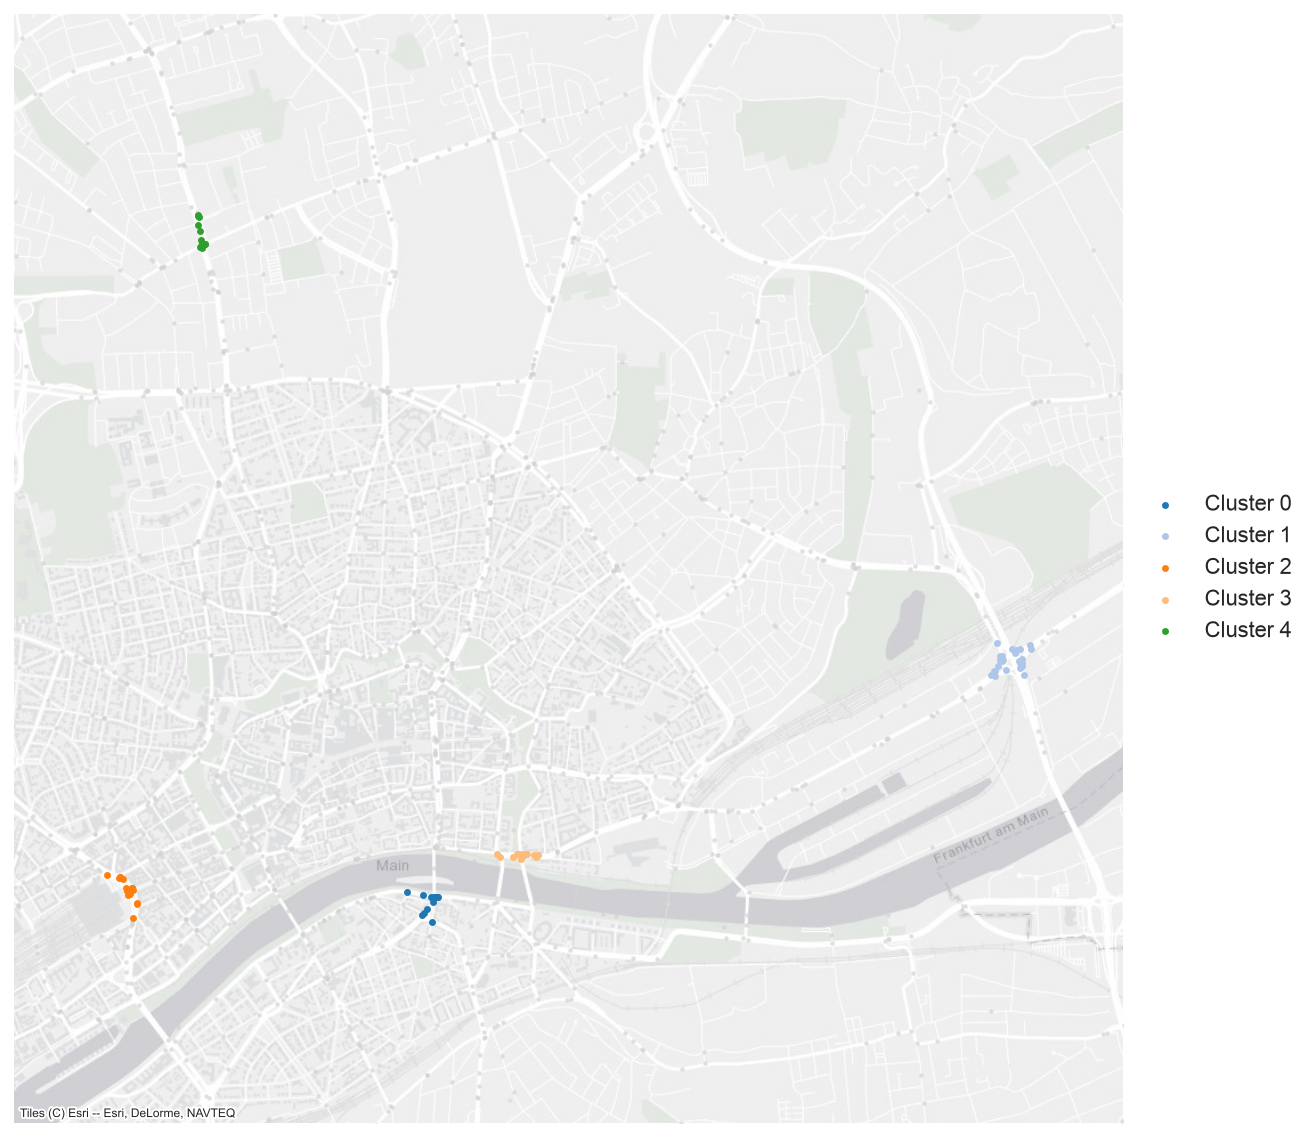

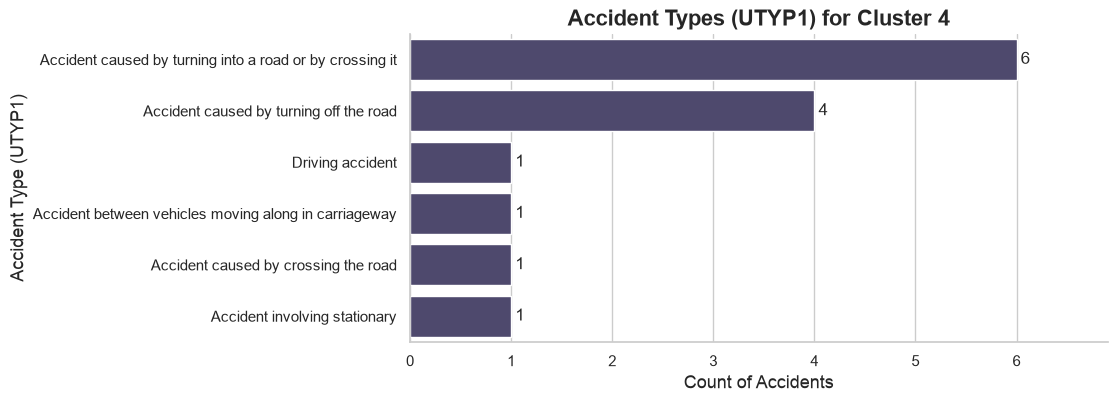

In [10]:
# Serious injury Clusters
serious_clusters = analyze_clusters(
    Frankfurt[Frankfurt["UKATEGORIE"].isin([1, 2])],
    "serious",
    eps=100,
    min_samples=14,
    cluster_to_plot=4,
)

In [11]:
print("--- Accident Counts per UKATEGORIE (for each Cluster) ---")
category_counts = (
    serious_clusters.groupby("labels")["UKATEGORIE"].value_counts().sort_index()
)
print(category_counts)

--- Accident Counts per UKATEGORIE (for each Cluster) ---
labels  UKATEGORIE
0       2             17
1       2             25
2       2             22
3       1              1
        2             16
4       2             14
Name: count, dtype: int64


## Exploration
The cells below come from an earlier exploratory notebook (`frankfurt.ipynb`, merged into this one). They look at the data from a few more angles and break the clusters found above down by accident type, category and lighting.

Mean center of the accidents involving a bicycle, plotting only those accidents.

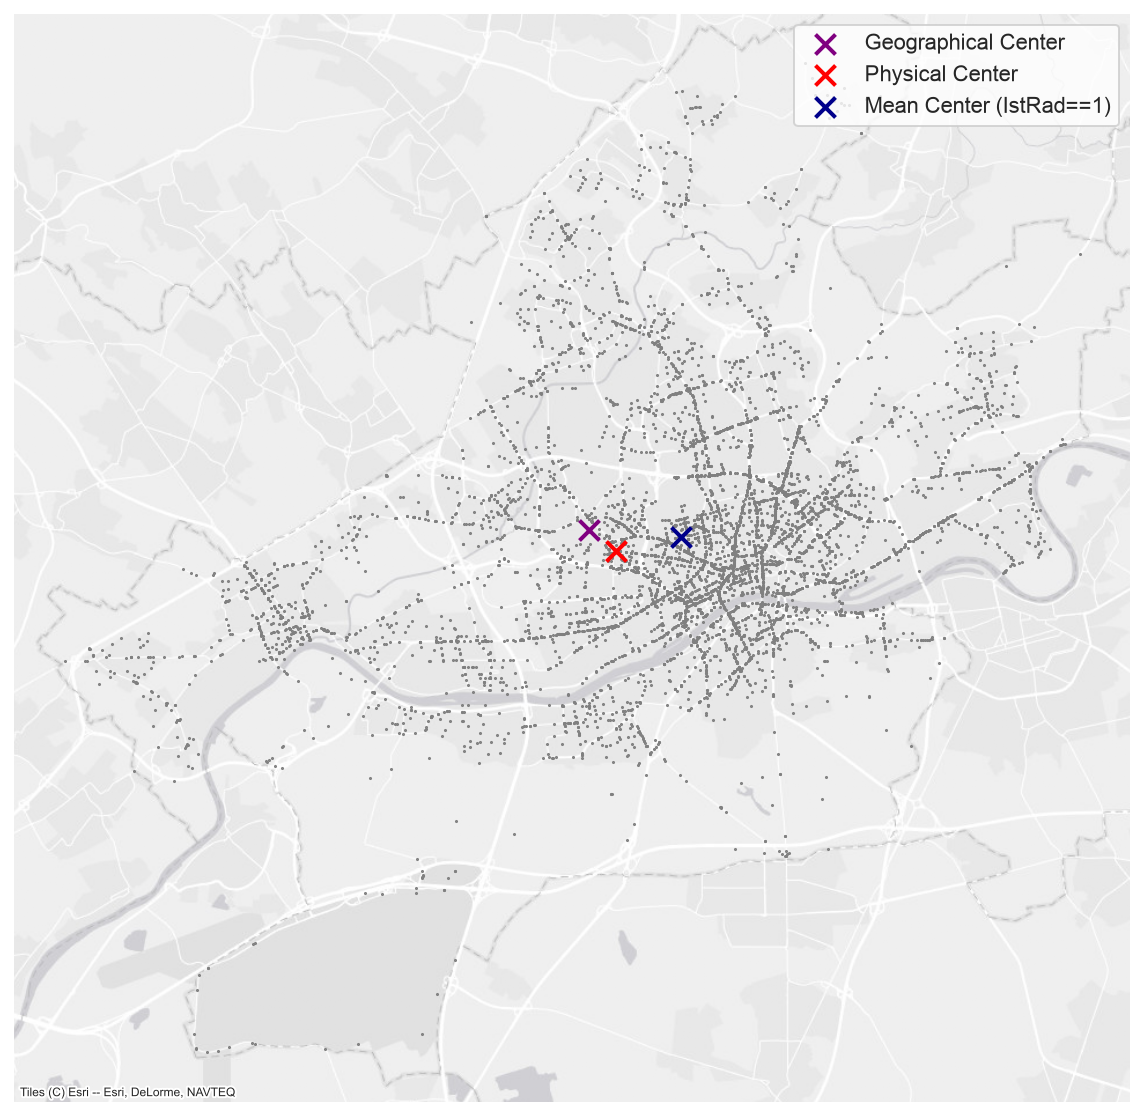

In [12]:
Frankfurt_Rad = Frankfurt[Frankfurt["IstRad"] == 1]
centers = pl.FFM_CENTERS + pl.mean_centers(
    Frankfurt_Rad, [("IstRad", "darkblue", "IstRad==1")]
)

fig, ax = plt.subplots(figsize=(10, 10), dpi=144)
pl.point_map(Frankfurt_Rad, size=0.3, alpha=1, centers=centers, ax=ax)
plt.show()

Accident points on top of the city districts and the road network (each layer is skipped with a warning if it cannot be loaded).

City Districts loaded.


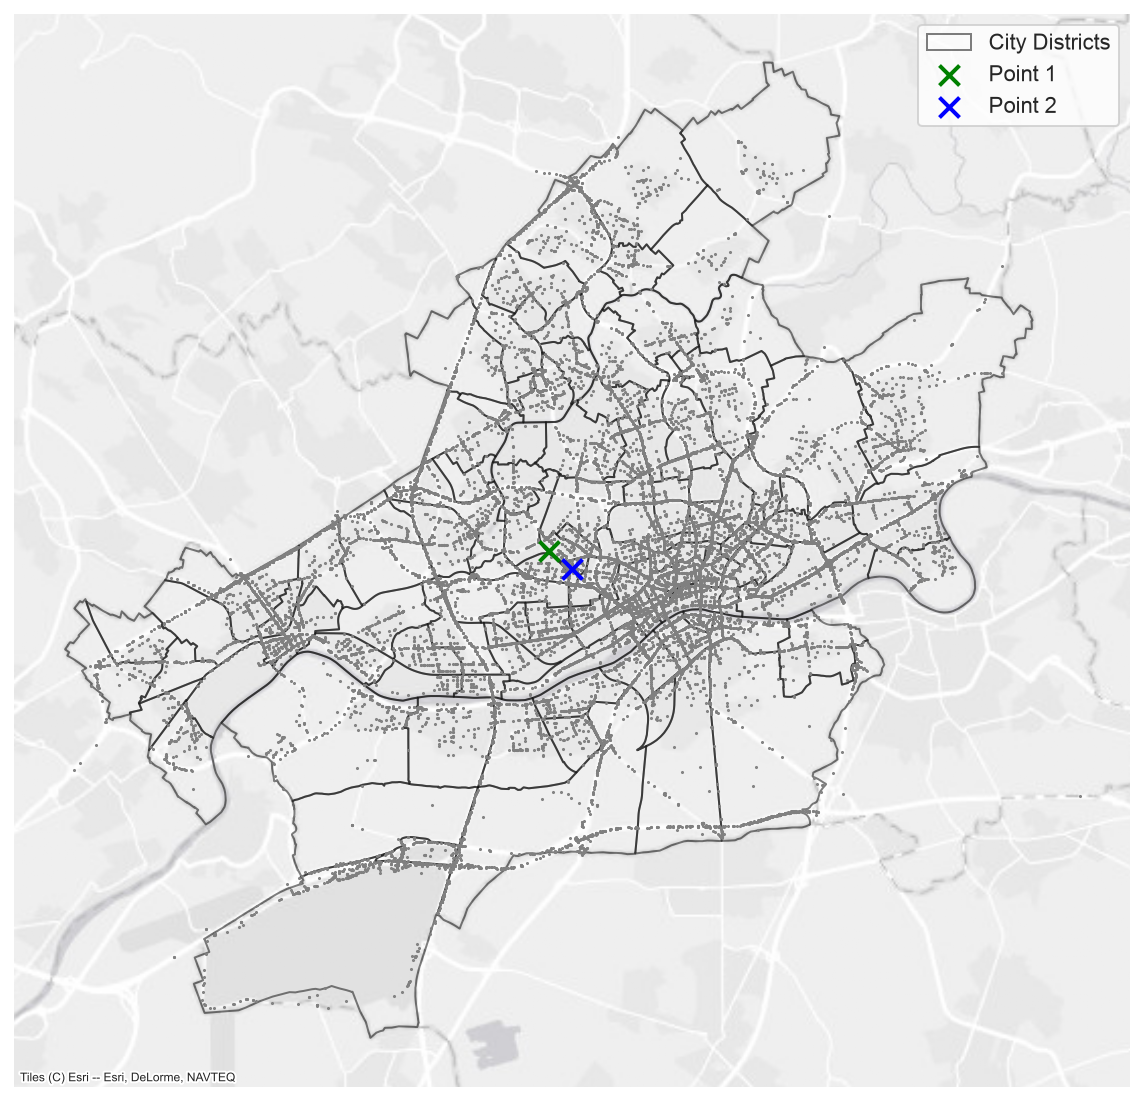

In [13]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=144)

wfs_url = "https://geowebdienste.frankfurt.de/WFS_Stadtgebietsgliederung?request=GetFeature&service=WFS&version=1.1.0&typeName=Stadtgebietsgliederung:Stadtbezirke&outputFormat=GML3"

try:
    districts_gdf = cached(
        f"{cfg.output.artifacts}/frankfurt/districts.parquet",
        lambda: gpd.read_file(wfs_url),
        gpd.read_parquet,
        lambda gdf, path: gdf.to_parquet(path),
        force=cfg.run.force_recompute,
    )
    print("City Districts loaded.")

    # Re-project
    districts_gdf_wm = districts_gdf.to_crs(epsg=3857)

    districts_gdf_wm.plot(
        ax=ax,
        facecolor="none",  # No fill
        edgecolor="black",  # Black outlines
        linewidth=1.0,
        alpha=0.5,  # Semi-transparent outlines
        label="City Districts",
    )
except Exception as e:
    print(
        f"WARNING: Could not load City Districts from WFS. Skipping this layer. Error: {e}"
    )

shapefile_path = resolve_path(f"{cfg.data.raw}/roads.zip")

try:
    roads_gdf = gpd.read_file(shapefile_path)
    print("Road network loaded.")
    roads_gdf_wm = roads_gdf.to_crs(epsg=3857)

    roads_gdf_wm.plot(
        ax=ax, edgecolor="gray", linewidth=0.5, alpha=0.7, label="Road Network"
    )
except Exception as e:
    print(
        f"WARNING: Could not load roads.zip. Expected it in the raw data folder (data.raw). Skipping this layer. Error: {e}"
    )

# The two city centres again, in other colors
centers = [
    (lat, lon, color, label)
    for (lat, lon, _, _), color, label in zip(
        pl.FFM_CENTERS, ["green", "blue"], ["Point 1", "Point 2"]
    )
]
pl.point_map(Frankfurt, size=0.3, alpha=1, ax=ax, centers=centers)
plt.show()

A k-distance graph with k = 5 for comparison with k = 20 above.

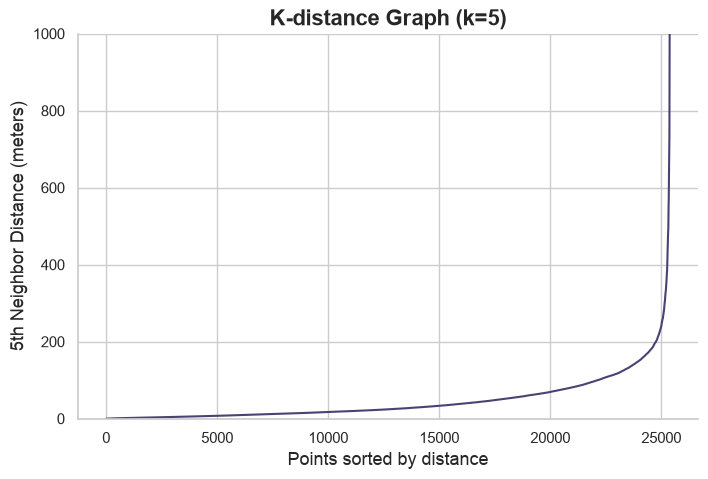

In [14]:
k = 5
fig, ax = plt.subplots(figsize=(8, 5))
pl.knn_distance(knn_distances(Frankfurt, k), k, f"K-distance Graph (k={k})", ax=ax)
ax.set_ylabel(f"{k}th Neighbor Distance (meters)")
ax.set_ylim(0, 1000)
plt.show()

Breakdown of all accident clusters by accident category.

In [15]:
print("--- Breakdown of Accident Category (UTYP1) by Cluster ---")
print(all_clusters.groupby("labels")["UTYP1"].value_counts())

--- Breakdown of Accident Category (UTYP1) by Cluster ---
labels  UTYP1                                                   
0       Accident between vehicles moving along in carriageway       172
        Accident caused by turning into a road or by crossing it     39
        Accident caused by turning off the road                       5
        Other accident                                                5
        Accident caused by crossing the road                          4
        Driving accident                                              4
        Accident involving stationary                                 1
1       Accident caused by turning off the road                      48
        Accident between vehicles moving along in carriageway        36
        Accident caused by turning into a road or by crossing it     20
        Other accident                                                4
        Driving accident                                              2
        Accid

Breakdown of the bicycle clusters.

In [16]:
print("--- Breakdown of Accident Type (UART) by Cluster ---")
print(bicycle_clusters.groupby("labels")["UART"].value_counts())
print("\n--- Breakdown of Accident Category (UTYP1) by Cluster ---")
print(bicycle_clusters.groupby("labels")["UTYP1"].value_counts())
print("\n--- Breakdown of Lighting (ULICHTVERH) by Cluster ---")
print(bicycle_clusters.groupby("labels")["ULICHTVERH"].value_counts())

--- Breakdown of Accident Type (UART) by Cluster ---
labels  UART
0       3       29
        5       19
        0        5
        2        3
        1        1
        6        1
1       3       25
        5       10
        0        4
        6        3
        2        2
        4        1
        1        1
2       5       15
        3       12
        0        8
        2        4
        6        4
        1        3
        4        2
3       5       20
        3        7
        4        5
        6        4
        0        4
        7        3
        1        3
        2        2
        8        1
4       5       17
        3        8
        0        8
        4        7
        6        2
        2        2
        7        1
        8        1
Name: count, dtype: int64

--- Breakdown of Accident Category (UTYP1) by Cluster ---
labels  UTYP1                                                   
0       Accident caused by turning off the road                     34
        Ac

In [17]:
# Show all original data for accidents in bicycle Cluster 0
bicycle_clusters[bicycle_clusters["labels"] == 0]

,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,UART,...,IstFuss,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84,District_key,labels
11630,06,4,12,000,2016,3,8,6,3,3,...,0,0,0.0,1,477414.859100,5.553372e+06,8.683993,50.132156,06412,0
13636,06,4,12,000,2016,4,12,6,3,3,...,0,0,0.0,0,477400.554100,5.553321e+06,8.683796,50.131693,06412,0
15875,06,4,12,000,2016,7,7,4,3,5,...,0,0,0.0,0,477428.382000,5.553314e+06,8.684186,50.131634,06412,0
16385,06,4,12,000,2016,7,19,6,3,3,...,0,0,0.0,0,477416.775600,5.553438e+06,8.684016,50.132747,06412,0
16402,06,4,12,000,2016,7,9,2,3,3,...,0,0,0.0,0,477410.786500,5.553327e+06,8.683939,50.131747,06412,0
16700,06,4,12,000,2016,7,20,3,3,5,...,0,0,0.0,0,477414.463600,5.553368e+06,8.683988,50.132116,06412,0
105726,06,4,12,000,2016,7,10,6,2,5,...,0,0,0.0,0,477333.870000,5.553342e+06,8.682862,50.131884,06412,0
105829,06,4,12,000,2016,6,10,4,2,3,...,0,0,0.0,0,477390.743400,5.553324e+06,8.683658,50.131722,06412,0
27033,06,4,12,000,2017,1,15,5,3,6,...,1,0,NaN,0,477409.970000,5.553318e+06,8.683928,50.131666,06412,0
33730,06,4,12,000,2017,7,8,3,3,3,...,0,0,NaN,0,477416.724100,5.553443e+06,8.684015,50.132795,06412,0


Breakdown of the pedestrian clusters.

In [18]:
print("--- Breakdown of Accident Category (UTYP1) by Cluster ---")
print(pedestrian_clusters.groupby("labels")["UTYP1"].value_counts())
print("\n--- Breakdown of Lighting (ULICHTVERH) by Cluster ---")
print(pedestrian_clusters.groupby("labels")["ULICHTVERH"].value_counts())

--- Breakdown of Accident Category (UTYP1) by Cluster ---
labels  UTYP1                                                
0       Accident caused by crossing the road                     14
        Other accident                                            6
        Accident caused by turning off the road                   3
        Accident between vehicles moving along in carriageway     1
        Driving accident                                          1
1       Accident caused by crossing the road                     60
        Other accident                                           23
        Accident caused by turning off the road                   7
        Accident between vehicles moving along in carriageway     4
        Driving accident                                          1
2       Accident caused by crossing the road                     14
        Accident caused by turning off the road                   8
        Other accident                                          

Breakdown of the night time clusters.

In [19]:
print("--- Breakdown of Accident Category (UTYP1) by Cluster ---")
print(night_clusters.groupby("labels")["UTYP1"].value_counts())

--- Breakdown of Accident Category (UTYP1) by Cluster ---
labels  UTYP1                                                   
0       Accident between vehicles moving along in carriageway       26
        Accident caused by turning into a road or by crossing it    10
        Accident caused by turning off the road                      1
        Other accident                                               1
1       Accident between vehicles moving along in carriageway       22
        Other accident                                               5
        Accident caused by turning off the road                      4
        Accident caused by turning into a road or by crossing it     4
        Driving accident                                             1
        Accident caused by crossing the road                         1
2       Accident between vehicles moving along in carriageway       14
        Accident caused by turning off the road                      8
        Accident caused b